In [ ]:
from PIL import Image
import requests
import torch
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

torch.set_printoptions(sci_mode=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:
inputs = processor(
    text=["a ship", "a photo of a ship in a frame", "playing cards", "a fan of playing cards"],
    images=image4,
    return_tensors="pt",
    padding=True)

inputs

{'pixel_values': tensor([[[[-0.4054, -0.4054, -0.4200,  ..., -0.2010, -0.0405, -0.0842],
          [-0.3762, -0.3324, -0.3324,  ..., -0.2302, -0.1426, -0.0405],
          [-0.3324, -0.4200, -0.4346,  ..., -0.1572, -0.1864, -0.0842],
          ...,
          [-0.0405, -0.0113, -0.0405,  ..., -1.2375, -1.0039, -0.9018],
          [-0.2594, -0.2740, -0.1718,  ..., -1.2083, -1.0769, -0.9018],
          [-0.2302, -0.2448, -0.0113,  ..., -1.1061, -1.0185, -0.7558]],

         [[-0.6865, -0.6565, -0.6715,  ..., -0.3264, -0.2813, -0.2213],
          [-0.6715, -0.6115, -0.6265,  ..., -0.3714, -0.2813, -0.1763],
          [-0.5965, -0.6265, -0.5965,  ..., -0.4014, -0.3414, -0.2063],
          ...,
          [-0.2963, -0.1313, -0.1463,  ..., -1.3019, -1.1668, -1.0617],
          [-0.4764, -0.4314, -0.3864,  ..., -1.2718, -1.1818, -1.0317],
          [-0.3414, -0.3864, -0.2663,  ..., -1.2418, -1.1218, -0.9267]],

         [[-0.6128, -0.6128, -0.6412,  ..., -0.2857, -0.1862, -0.1151],
          [-0

In [ ]:
inputs.pixel_values.shape

torch.Size([1, 3, 224, 224])

In [ ]:
outputs = model(**inputs)
logits_per_image = outputs.logits_per_image  # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1)  # we can take the softmax to get the label probabilities

probs

tensor([[0.0001, 0.0000, 0.5835, 0.4163]], grad_fn=<SoftmaxBackward0>)

In [ ]:
inputs = processor(
    text=["a ship", "a photo of a ship in a frame", "playing cards", "a fan of playing cards"],
    images=images,
    return_tensors="pt",
    padding=True)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image  # this is the image-text similarity score
probs = logits_per_image.softmax(dim=1)  # we can take the softmax to get the label probabilities

probs

tensor([[0.5549, 0.4449, 0.0001, 0.0001],
        [0.2436, 0.7562, 0.0000, 0.0001],
        [0.0433, 0.9553, 0.0011, 0.0003],
        [0.0001, 0.0000, 0.5835, 0.4163],
        [0.0001, 0.0000, 0.2056, 0.7943],
        [0.0007, 0.0001, 0.7893, 0.2099]], grad_fn=<SoftmaxBackward0>)

In [ ]:
# Obtain image embeddings

image1_preprocess = processor(images=image1, return_tensors="pt")['pixel_values']
image1_embedding = model.get_image_features(image1_preprocess).pooler_output

image2_preprocess = processor(images=image2, return_tensors="pt")['pixel_values']
image2_embedding = model.get_image_features(image2_preprocess).pooler_output

image1_embedding.shape

torch.Size([1, 512])

In [ ]:
import torch

similarity_score = torch.nn.functional.cosine_similarity(image1_embedding, image2_embedding)
similarity_score

tensor([0.7089], grad_fn=<SumBackward1>)

In [ ]:
import pandas as pd
import seaborn as sns

def compute_similarity(images):
    embeddings = []

    with torch.no_grad():
        for image in images:
            preprocess = processor(images=image, return_tensors="pt")['pixel_values']
            embedding = model.get_image_features(preprocess).pooler_output
            embeddings.append(embedding)

    num_images = len(images)
    similarity_matrix = torch.zeros((num_images, num_images))

    with torch.no_grad():
        for i in range(num_images):
            for j in range(num_images):
                similarity_matrix[i, j] = torch.nn.functional.cosine_similarity(embeddings[i], embeddings[j])

    similarity_matrix = similarity_matrix.detach().numpy()
    image_labels = [f"Image {i+1}" for i in range(num_images)]
    similarity_df = pd.DataFrame(similarity_matrix, index=image_labels, columns=image_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(similarity_df, annot=True, cmap='Greens', linewidths=.5, cbar_kws={'label': 'Similarity'})
    plt.title("Image Similarity Heatmap")
    plt.show()

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for idx, image in enumerate(images):
        if image.mode == 'L':
            axes[idx].imshow(image, cmap='gray')
        else:
            axes[idx].imshow(image)
        axes[idx].set_title(f"Image {idx+1}")
        axes[idx].axis("off")

    plt.show()

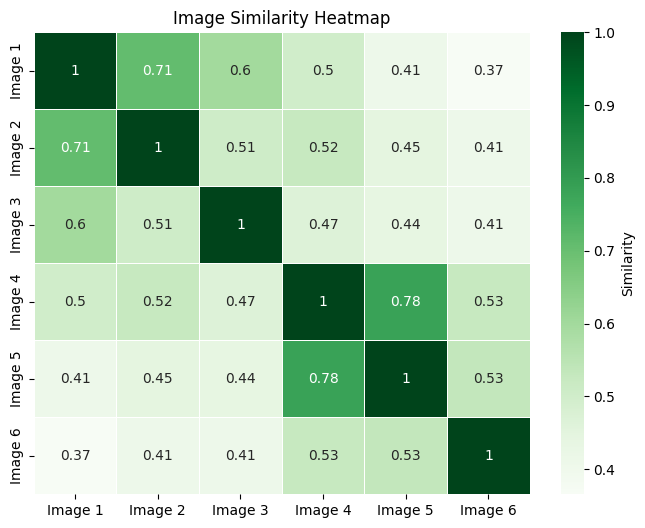

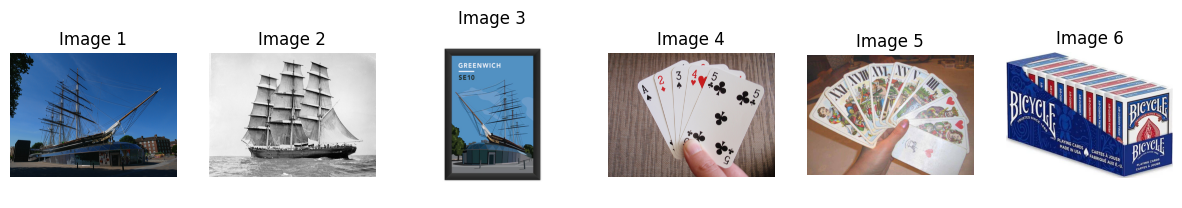

In [ ]:
compute_similarity(images)